In [1]:
import pandas as pd
import numpy as np

import nltk
import re
import string

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("//content/email_spam.csv", encoding='latin1')

In [3]:
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
data.shape

(5572, 5)

In [5]:
data.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [6]:
data.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
data.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [9]:
data.nunique()

,0
v1,2
v2,5169
Unnamed: 2,43
Unnamed: 3,10
Unnamed: 4,5


In [10]:
data['v1'].unique()

array(['ham', 'spam'], dtype=object)

In [11]:
data['v1'].value_counts()

,count
v1,
ham,4825
spam,747


In [12]:
(data.isnull().sum()/len(data))*100

,0
v1,0.000000
v2,0.000000
Unnamed: 2,99.102656
Unnamed: 3,99.784637
Unnamed: 4,99.892319


In [13]:
data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [14]:
data.sample(5)

,v1,v2
3439,ham,What time you thinkin of goin?
5530,ham,I think that tantrum's finished so yeah I'll b...
699,ham,K..u also dont msg or reply to his msg..
3753,spam,Bloomberg -Message center +447797706009 Why wa...
1156,ham,Hey.. Something came up last min.. Think i wun...


In [15]:
data.rename(columns={'v1':'label', 'v2':'message'}, inplace=True)

In [16]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
data["target"]=encoder.fit_transform(data["label"])

In [17]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

data['clean_message'] = data['message'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [18]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    data["clean_message"]
)

y = data["label"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)

MultinomialNB()

In [21]:
y_pred = mnb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='spam'))
print("Recall:", recall_score(y_test, y_pred, pos_label='spam'))
print("F1 Score:", f1_score(y_test, y_pred, pos_label='spam'))

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9659192825112107
Precision: 1.0
Recall: 0.7466666666666667
F1 Score: 0.8549618320610687

Classification Report:
               precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115


Confusion Matrix:
 [[965   0]
 [ 38 112]]


In [22]:
print(data)

     label                                            message  target  \
0      ham  Go until jurong point, crazy.. Available only ...       0   
1      ham                      Ok lar... Joking wif u oni...       0   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...       1   
3      ham  U dun say so early hor... U c already then say...       0   
4      ham  Nah I don't think he goes to usf, he lives aro...       0   
...    ...                                                ...     ...   
5567  spam  This is the 2nd time we have tried 2 contact u...       1   
5568   ham              Will Ì_ b going to esplanade fr home?       0   
5569   ham  Pity, * was in mood for that. So...any other s...       0   
5570   ham  The guy did some bitching but I acted like i'd...       0   
5571   ham                         Rofl. Its true to its name       0   

                                          clean_message  
0     go jurong point crazy available bugis n great ...  
1      

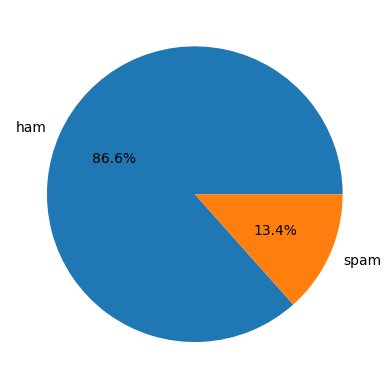

In [23]:
plt.pie(data["target"].value_counts(),labels=['ham','spam'],autopct='%1.1f%%')
plt.show()

In [24]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [25]:
y_pred = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

precision_score(y_test, y_pred, pos_label='spam')

recall_score(y_test, y_pred, pos_label='spam')

f1_score(y_test, y_pred, pos_label='spam')

print(
    classification_report(
        y_test,
        y_pred
    )
)

0.9659192825112107
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.75      0.85       150

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



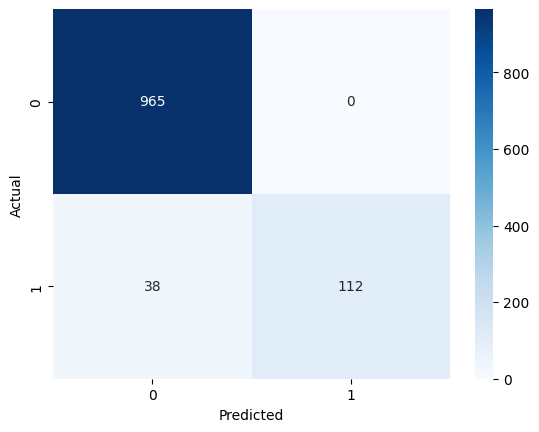

In [29]:
import seaborn as sns
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
message = input("Enter message: ")

processed = clean_text(message)

vector = vectorizer.transform([processed])

prediction = model.predict(vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Enter message: 1
Not Spam


In [31]:
model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [33]:
model = LinearSVC()

model.fit(X_train, y_train)

predictions = model.predict(X_test)